In [668]:
# Imported pandas,seaborn,numpy and statistics
import pandas as pd
import seaborn as sea
import numpy as np
import statistics as st

In [669]:
# Loading the train data
data = pd.read_csv('/content/train_LZdllcl.csv')
data.head(3)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0


In [670]:
# Checked for Duplicate values in data
print("Duplicates count in the given data:",data.duplicated().sum())

Duplicates count in the given data: 0


In [671]:
data['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


In [672]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [673]:
# Check if there is any Null value
data.isnull().mean()*100

,0
employee_id,0.000000
department,0.000000
region,0.000000
education,4.395344
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.524449
length_of_service,0.000000


In [674]:
# First let's solve the null value in gender using 'mode', since it is a object
Gender = data['education']
st.mode(data['education'])
data['education'].fillna(st.mode(data['education']),inplace=True)

In [675]:
# Check if there is any Null value
data.isnull().mean()*100


,0
employee_id,0.000000
department,0.000000
region,0.000000
education,0.000000
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.524449
length_of_service,0.000000


In [676]:
# previous_year_rating is  float, so we can use median with fillna()
previous_year_rating = data['previous_year_rating']
st.mode(data['previous_year_rating'])
data['previous_year_rating'].fillna(st.mode(data['previous_year_rating']),inplace=True)

In [677]:
data.isnull().mean()*100

,0
employee_id,0.0
department,0.0
region,0.0
education,0.0
gender,0.0
recruitment_channel,0.0
no_of_trainings,0.0
age,0.0
previous_year_rating,0.0
length_of_service,0.0


In [678]:
# Getting the info to check missing values
data.info()
# No Missing missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             54808 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  54808 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


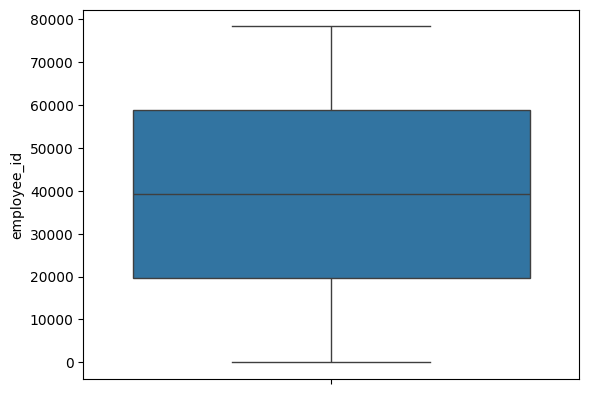

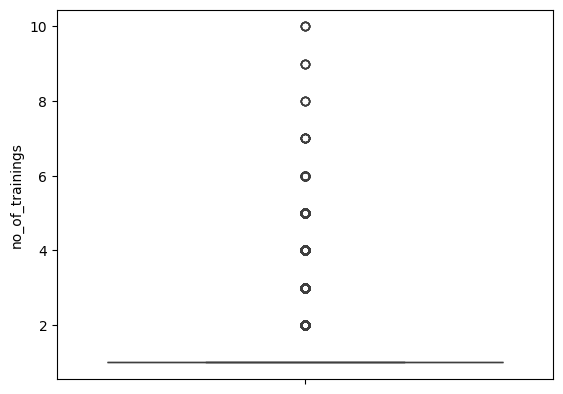

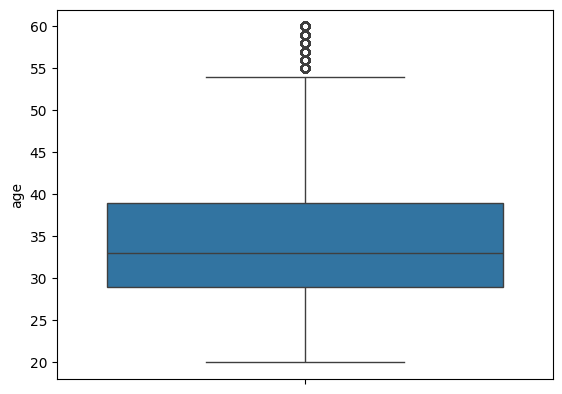

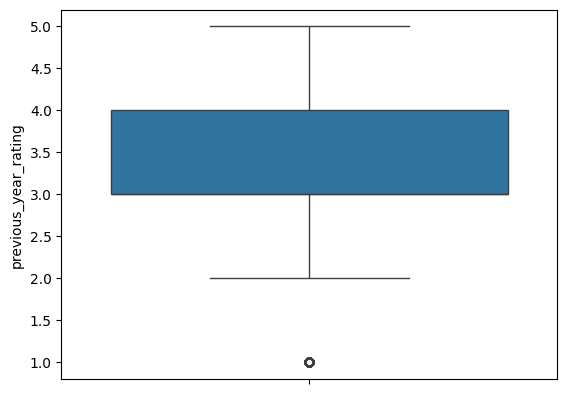

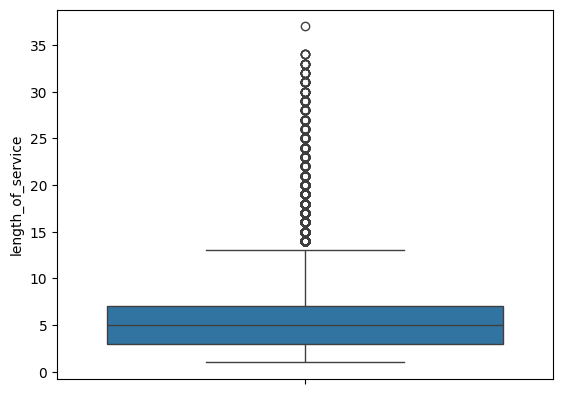

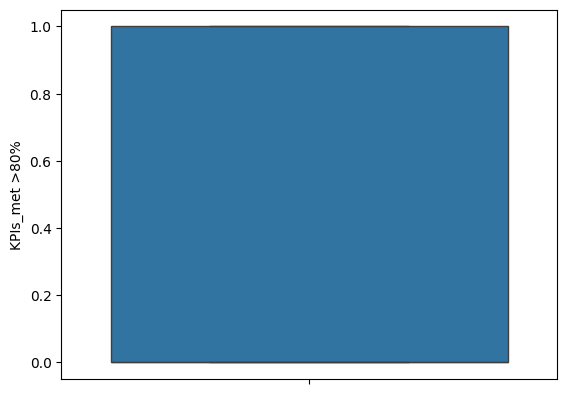

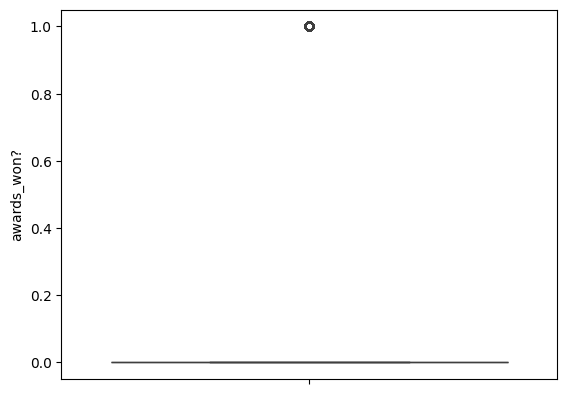

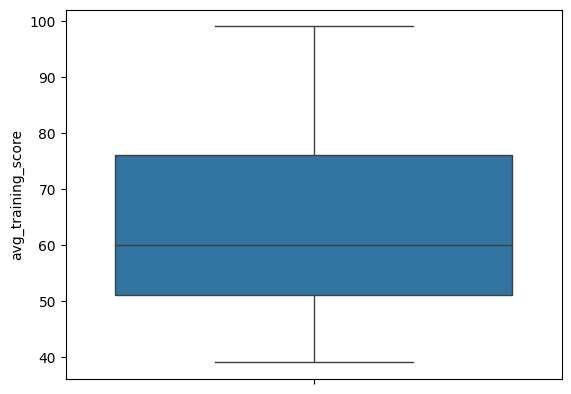

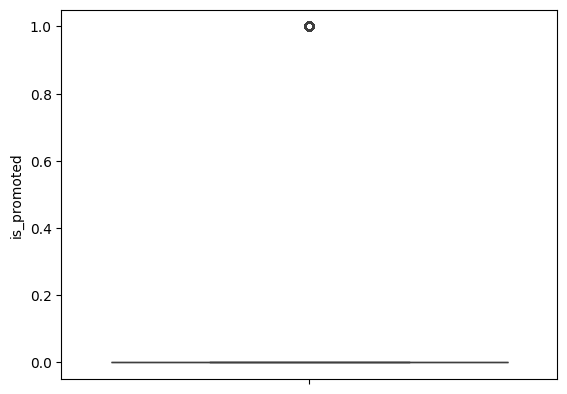

In [679]:
# Now Lets's check for outliners in data
import matplotlib.pyplot as plt

numericals = data.select_dtypes("number")
for i in numericals.columns:
  sea.boxplot(data[i])
  plt.show()

In [680]:
# Now let's check the skewness
for i in numericals:
  print("Skewness of ",i,"is :-",numericals[i].skew())

Skewness of  employee_id is :- -0.0031279471733061466
Skewness of  no_of_trainings is :- 3.445433937567454
Skewness of  age is :- 1.0074317710382241
Skewness of  previous_year_rating is :- -0.2608580288123413
Skewness of  length_of_service is :- 1.738061458740809
Skewness of  KPIs_met >80% is :- 0.61990886872196
Skewness of  awards_won? is :- 6.338913659392756
Skewness of  avg_training_score is :- 0.45190808551707995
Skewness of  is_promoted is :- 2.9723390958099434


In [681]:
# Lets's handle the outliers by clipping
Q1 = data['no_of_trainings'].quantile(0.25)
print("Q1:-",Q1)
Q3 = data['no_of_trainings'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)

Q1:- 1.0
Q1:- 1.0
IQR:- 0.0


In [682]:
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)

Lower Limit is :- 1.0
Upper Limit is :- 1.0


In [683]:
data['no_of_trainings'].clip(lower=Lower, upper=Upper, inplace=True)

/tmp/ipykernel_9515/959041632.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['no_of_trainings'].clip(lower=Lower, upper=Upper, inplace=True)


In [684]:
# Lets's handle the outliers by clipping
Q1 = data['age'].quantile(0.25)
print("Q1:-",Q1)
Q3 = data['age'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)

Q1:- 29.0
Q1:- 39.0
IQR:- 10.0


In [685]:
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)

Lower Limit is :- 14.0
Upper Limit is :- 54.0


In [686]:
data['age'].clip(lower=Lower, upper=Upper, inplace=True)

/tmp/ipykernel_9515/1797558253.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].clip(lower=Lower, upper=Upper, inplace=True)


In [687]:
Q1 = data['previous_year_rating'].quantile(0.25)
print("Q1:-",Q1)
Q3 = data['previous_year_rating'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)
data['previous_year_rating'].clip(lower=Lower, upper=Upper, inplace=True)

Q1:- 3.0
Q1:- 4.0
IQR:- 1.0
Lower Limit is :- 1.5
Upper Limit is :- 5.5


In [688]:
Q1 = data['length_of_service'].quantile(0.25)
print("Q1:-",Q1)
Q3 = data['length_of_service'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)
data['length_of_service'].clip(lower=Lower, upper=Upper, inplace=True)

Q1:- 3.0
Q1:- 7.0
IQR:- 4.0
Lower Limit is :- -3.0
Upper Limit is :- 13.0


/tmp/ipykernel_9515/3652142723.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['length_of_service'].clip(lower=Lower, upper=Upper, inplace=True)


In [689]:
Q1 = data['awards_won?'].quantile(0.25)
print("Q1:-",Q1)
Q3 = data['awards_won?'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)
data['awards_won?'].clip(lower=Lower, upper=Upper, inplace=True)

Q1:- 0.0
Q1:- 0.0
IQR:- 0.0
Lower Limit is :- 0.0
Upper Limit is :- 0.0


/tmp/ipykernel_9515/3678455725.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['awards_won?'].clip(lower=Lower, upper=Upper, inplace=True)


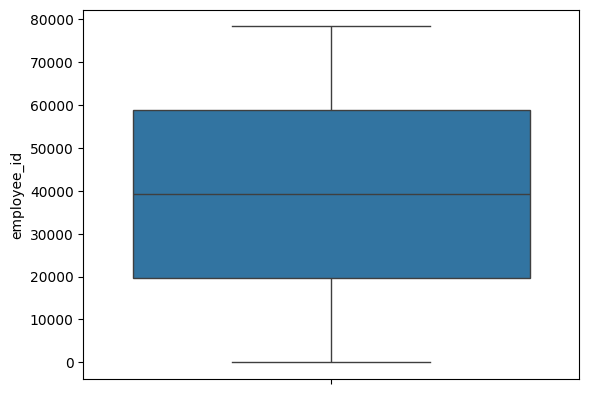

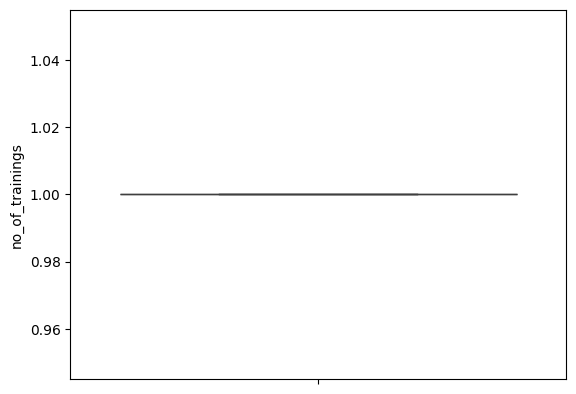

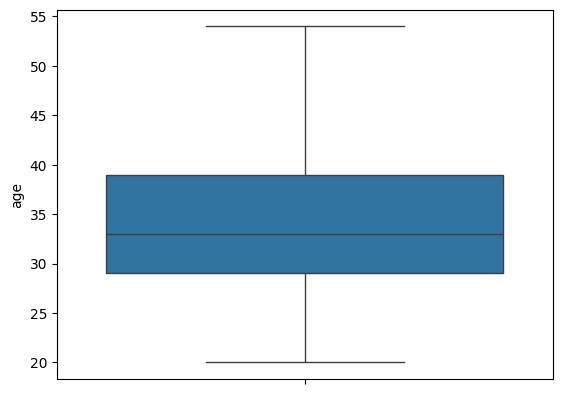

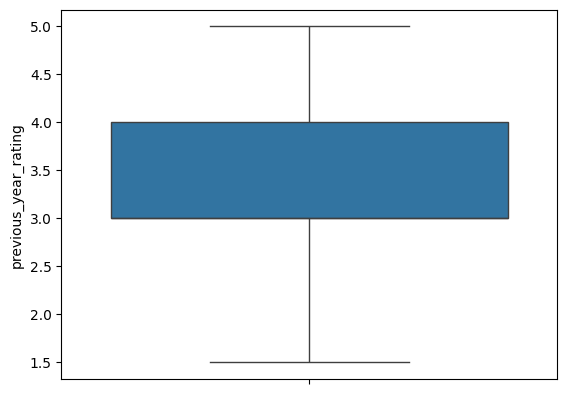

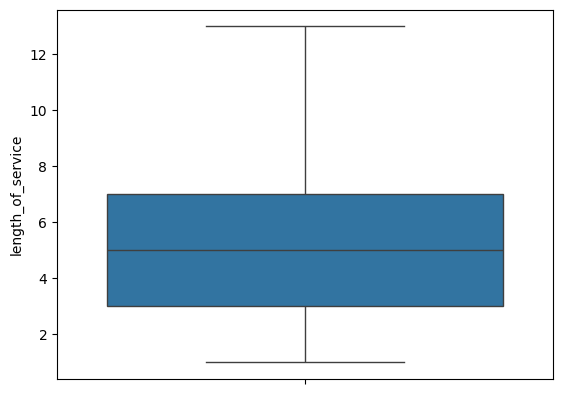

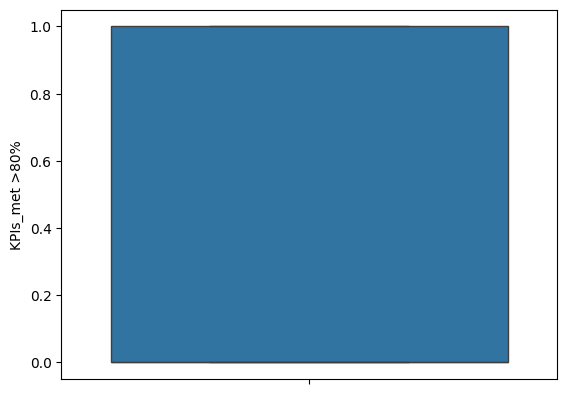

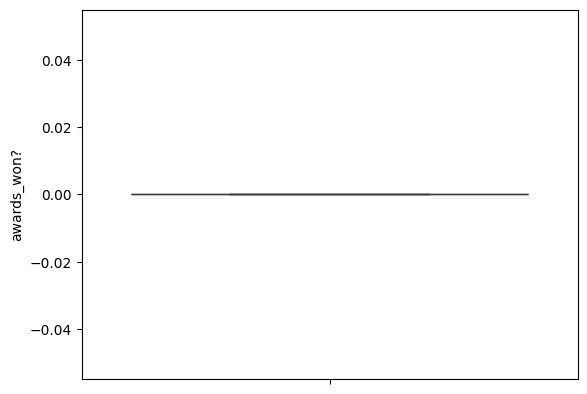

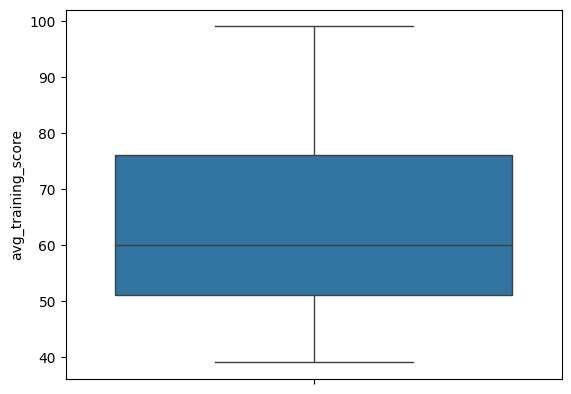

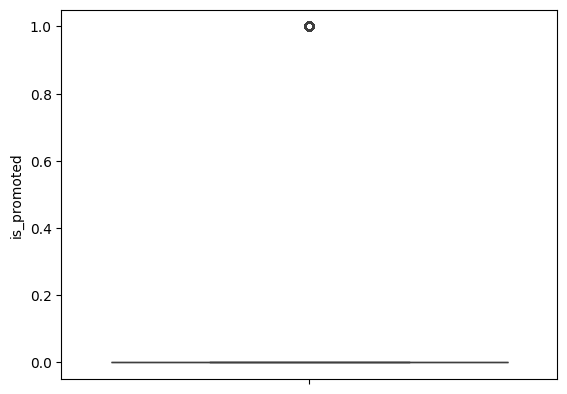

In [690]:
# Now Lets's check for outliners in data
import matplotlib.pyplot as plt

numericals = data.select_dtypes("number")
for i in numericals.columns:
  sea.boxplot(data[i])
  plt.show()

In [691]:
# Now let check the skewness
for i in numericals:
  print("Skewness of ",i,"is :-",data[i].skew())

Skewness of  employee_id is :- -0.0031279471733061466
Skewness of  no_of_trainings is :- 0.0
Skewness of  age is :- 0.8555525242716281
Skewness of  previous_year_rating is :- 0.03161467449141471
Skewness of  length_of_service is :- 0.7053582776541721
Skewness of  KPIs_met >80% is :- 0.61990886872196
Skewness of  awards_won? is :- 0.0
Skewness of  avg_training_score is :- 0.45190808551707995
Skewness of  is_promoted is :- 2.9723390958099434


In [692]:
data['age']=np.cbrt(data['age'])
data['length_of_service']=np.cbrt(data['length_of_service'])
data['KPIs_met >80%']=np.cbrt(data['KPIs_met >80%'])

In [693]:
#Now let's encode the cat values
cat = data.select_dtypes('object')
cat.head(3)

,department,region,education,gender,recruitment_channel
0,Sales & Marketing,region_7,Master's & above,f,sourcing
1,Operations,region_22,Bachelor's,m,other
2,Sales & Marketing,region_19,Bachelor's,m,sourcing


In [694]:
cat['recruitment_channel'].value_counts()

,count
recruitment_channel,
other,30446
sourcing,23220
referred,1142


In [695]:
cat = cat.drop(['region'],axis=1)

In [696]:
department_new = data.groupby('department')['KPIs_met >80%'].mean()
cat['department'] = cat['department'].map(department_new)

In [697]:
cat.head(3)

,department,education,gender,recruitment_channel
0,0.265083,Master's & above,f,sourcing
1,0.430737,Bachelor's,m,other
2,0.265083,Bachelor's,m,sourcing


In [698]:
cat_colum = cat.select_dtypes('object').columns
cat_colum

Index(['education', 'gender', 'recruitment_channel'], dtype='object')

In [699]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore',drop='first', sparse_output=False)  # sparse=False forces dense output
X_cat = ohe.fit_transform(data[cat_colum])
#Here we are creating a table that' swhy to get all column name we have given get_feature_names_out(cat_column)
X_cat = pd.DataFrame(X_cat, columns=ohe.get_feature_names_out(cat_colum), index=data.index)

In [700]:
X_cat

,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
54803,0.0,0.0,1.0,0.0,1.0
54804,0.0,1.0,0.0,0.0,0.0
54805,0.0,0.0,1.0,0.0,0.0
54806,0.0,0.0,1.0,0.0,1.0


In [701]:
X_cat['department']=cat['department']
X_cat

,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing,department
0,0.0,1.0,0.0,0.0,1.0,0.265083
1,0.0,0.0,1.0,0.0,0.0,0.430737
2,0.0,0.0,1.0,0.0,1.0,0.265083
3,0.0,0.0,1.0,0.0,0.0,0.265083
4,0.0,0.0,1.0,0.0,0.0,0.344354
...,...,...,...,...,...,...
54803,0.0,0.0,1.0,0.0,1.0,0.344354
54804,0.0,1.0,0.0,0.0,0.0,0.430737
54805,0.0,0.0,1.0,0.0,0.0,0.404148
54806,0.0,0.0,1.0,0.0,1.0,0.265083


In [702]:
Num_col= data.select_dtypes('number').columns
Num_col = Num_col.drop('is_promoted')

In [703]:
X_final = pd.concat([data[Num_col], X_cat], axis=1)

X_final.head(3)

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing,department
0,65438,1,3.271066,5.0,2.000000,1.0,0,49,0.0,1.0,0.0,0.0,1.0,0.265083
1,65141,1,3.107233,5.0,1.587401,0.0,0,60,0.0,0.0,1.0,0.0,0.0,0.430737
2,7513,1,3.239612,3.0,1.912931,0.0,0,50,0.0,0.0,1.0,0.0,1.0,0.265083


In [704]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_final[Num_col] = scaler.fit_transform(data[Num_col])
X_final


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing,department
0,1.161858,0.0,0.108949,1.472146,0.814727,1.356878,0.0,-1.075931,0.0,1.0,0.0,0.0,1.0,0.265083
1,1.148709,0.0,-0.621927,1.472146,-0.280246,-0.736986,0.0,-0.253282,0.0,0.0,1.0,0.0,0.0,0.430737
2,-1.402741,0.0,-0.031372,-0.324526,0.583660,-0.736986,0.0,-1.001145,0.0,0.0,1.0,0.0,1.0,0.265083
3,-1.622829,0.0,0.644926,-1.672029,1.224572,-0.736986,0.0,-1.001145,0.0,0.0,1.0,0.0,0.0,0.265083
4,0.431639,0.0,1.384047,-0.324526,-1.149326,-0.736986,0.0,0.718939,0.0,0.0,1.0,0.0,0.0,0.344354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,-1.601223,0.0,1.729102,-0.324526,1.747114,-0.736986,0.0,1.092871,0.0,0.0,1.0,0.0,1.0,0.344354
54804,1.567147,0.0,0.381769,-1.222861,0.329394,-0.736986,0.0,-0.552428,0.0,1.0,0.0,0.0,0.0,0.430737
54805,-1.119163,0.0,-1.100299,1.472146,-0.665455,1.356878,0.0,1.167657,0.0,0.0,1.0,0.0,0.0,0.404148
54806,-1.132622,0.0,-0.777688,-1.672029,-1.149326,-0.736986,0.0,-1.375077,0.0,0.0,1.0,0.0,1.0,0.265083


In [705]:
y= data['is_promoted']
y

,is_promoted
0,0
1,0
2,0
3,0
4,0
...,...
54803,0
54804,0
54805,0
54806,0


In [706]:
print(y.value_counts())

is_promoted
0    50140
1     4668
Name: count, dtype: int64


In [707]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [708]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X_final,y,random_state=42) #25% test 75% train

In [709]:
X_train.shape

(41106, 14)

In [710]:
y_train.shape

(41106,)

In [711]:
print(y_train.value_counts())
print(y_test.value_counts())

is_promoted
0    37569
1     3537
Name: count, dtype: int64
is_promoted
0    12571
1     1131
Name: count, dtype: int64


In [712]:
# Initialize and train the model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [713]:
test = pd.read_csv('/content/test_2umaH9m.csv')  # Loading the test data
test.head(3)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47


In [714]:
# Check if there is any Null value
test.isnull().mean()*100

,0
employee_id,0.000000
department,0.000000
region,0.000000
education,4.401873
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.713921
length_of_service,0.000000


In [715]:
# First let's solve the null value in gender using 'mode', since it is a object
Gender = test['education']
st.mode(test['education'])
test['education'].fillna(st.mode(test['education']),inplace=True)


In [716]:
# Check if there is any Null value
test.isnull().mean()*100


,0
employee_id,0.000000
department,0.000000
region,0.000000
education,0.000000
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.713921
length_of_service,0.000000


In [717]:
# previous_year_rating is  float, so we can use median with fillna()
previous_year_rating = test['previous_year_rating']
st.mode(test['previous_year_rating'])
test['previous_year_rating'].fillna(st.mode(test['previous_year_rating']),inplace=True)


In [718]:
test.isnull().mean()*100

,0
employee_id,0.0
department,0.0
region,0.0
education,0.0
gender,0.0
recruitment_channel,0.0
no_of_trainings,0.0
age,0.0
previous_year_rating,0.0
length_of_service,0.0


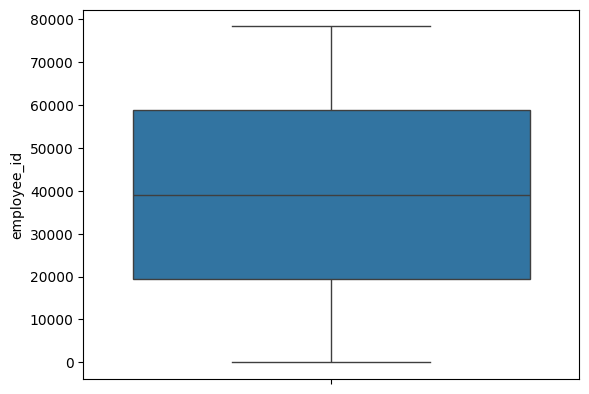

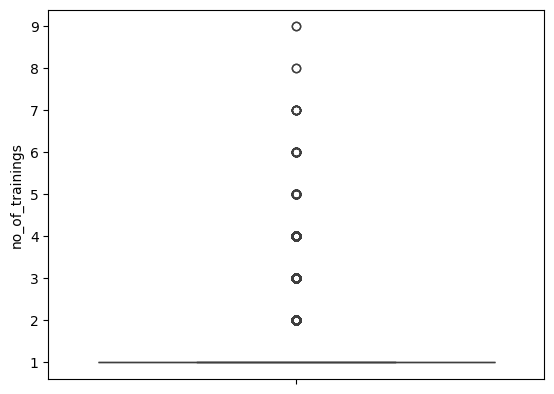

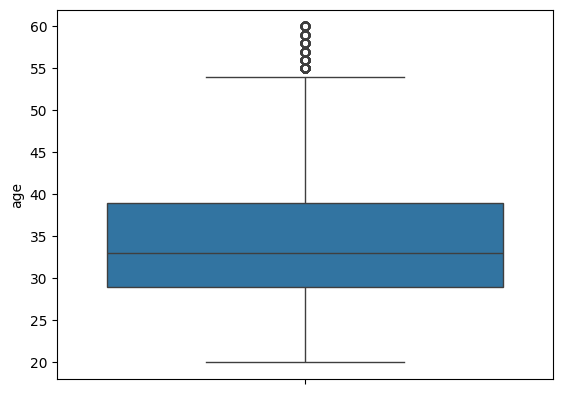

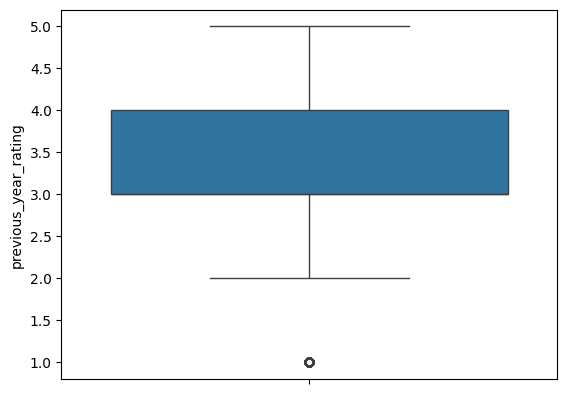

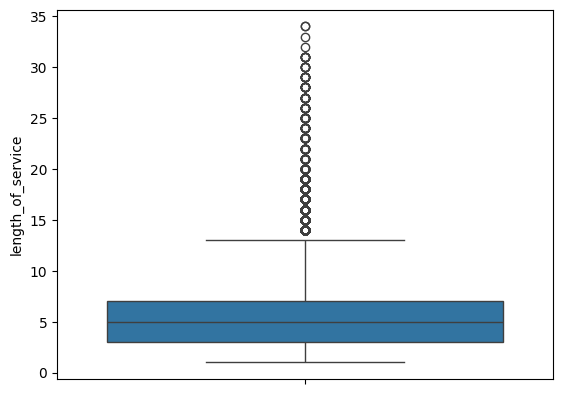

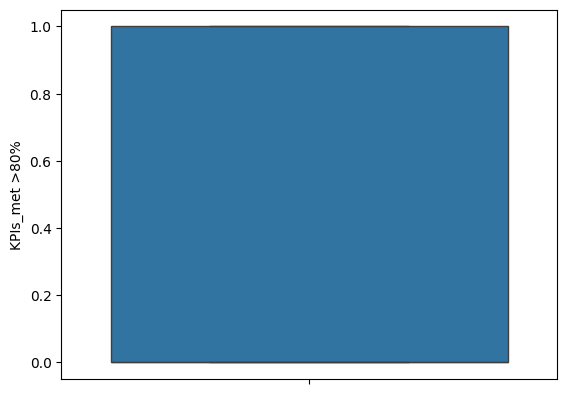

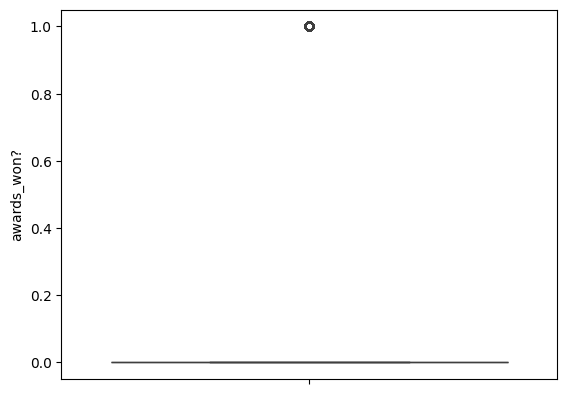

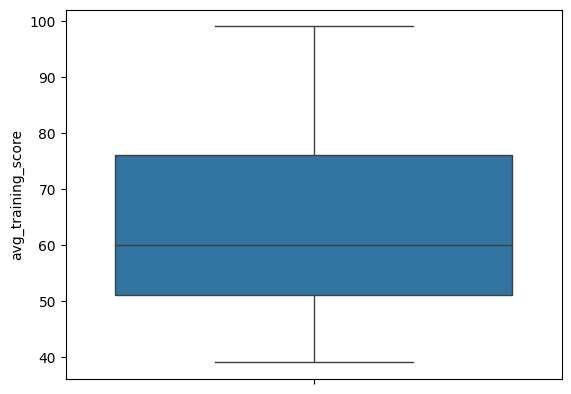

In [719]:
# Now Lets's check for outliners in data
import matplotlib.pyplot as plt

numerical = test.select_dtypes("number")
for i in numerical.columns:
  sea.boxplot(test[i])
  plt.show()


In [720]:
# Now let's check the skewness
for i in numerical:
  print("Skewness of ",i,"is :-",numerical[i].skew())


Skewness of  employee_id is :- 0.0073147709442498874
Skewness of  no_of_trainings is :- 3.299829240353573
Skewness of  age is :- 1.0117773507112382
Skewness of  previous_year_rating is :- -0.27236728067971216
Skewness of  length_of_service is :- 1.7030008581343499
Skewness of  KPIs_met >80% is :- 0.5886502332823661
Skewness of  awards_won? is :- 6.3980525498133405
Skewness of  avg_training_score is :- 0.4581131346053442


In [721]:
# Lets's handle the outliers by clipping
Q1 = test['no_of_trainings'].quantile(0.25)
print("Q1:-",Q1)
Q3 = test['no_of_trainings'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)

Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)

test['no_of_trainings'].clip(lower=Lower, upper=Upper, inplace=True)


Q1:- 1.0
Q1:- 1.0
IQR:- 0.0
Lower Limit is :- 1.0
Upper Limit is :- 1.0


/tmp/ipykernel_9515/1229842381.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['no_of_trainings'].clip(lower=Lower, upper=Upper, inplace=True)


In [722]:
# Lets's handle the outliers by clipping
Q1 = test['age'].quantile(0.25)
print("Q1:-",Q1)
Q3 = test['age'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)


Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)
test['age'].clip(lower=Lower, upper=Upper, inplace=True)


Q1:- 29.0
Q1:- 39.0
IQR:- 10.0
Lower Limit is :- 14.0
Upper Limit is :- 54.0


/tmp/ipykernel_9515/2396469502.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['age'].clip(lower=Lower, upper=Upper, inplace=True)


In [723]:
Q1 = test['previous_year_rating'].quantile(0.25)
print("Q1:-",Q1)
Q3 = test['previous_year_rating'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)
test['previous_year_rating'].clip(lower=Lower, upper=Upper, inplace=True)


Q1:- 3.0
Q1:- 4.0
IQR:- 1.0
Lower Limit is :- 1.5
Upper Limit is :- 5.5


In [724]:
Q1 = test['length_of_service'].quantile(0.25)
print("Q1:-",Q1)
Q3 = test['length_of_service'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)
test['length_of_service'].clip(lower=Lower, upper=Upper, inplace=True)


Q1:- 3.0
Q1:- 7.0
IQR:- 4.0
Lower Limit is :- -3.0
Upper Limit is :- 13.0


/tmp/ipykernel_9515/2235989187.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['length_of_service'].clip(lower=Lower, upper=Upper, inplace=True)


In [725]:
Q1 = test['awards_won?'].quantile(0.25)
print("Q1:-",Q1)
Q3 = test['awards_won?'].quantile(0.75)
print("Q1:-",Q3)
IQR = Q3-Q1
print("IQR:-",IQR)
Lower = (Q1-1.5*IQR)
Upper = (Q3+1.5*IQR)
print("Lower Limit is :-",Lower)
print("Upper Limit is :-",Upper)
test['awards_won?'].clip(lower=Lower, upper=Upper, inplace=True)


Q1:- 0.0
Q1:- 0.0
IQR:- 0.0
Lower Limit is :- 0.0
Upper Limit is :- 0.0


/tmp/ipykernel_9515/481380013.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['awards_won?'].clip(lower=Lower, upper=Upper, inplace=True)


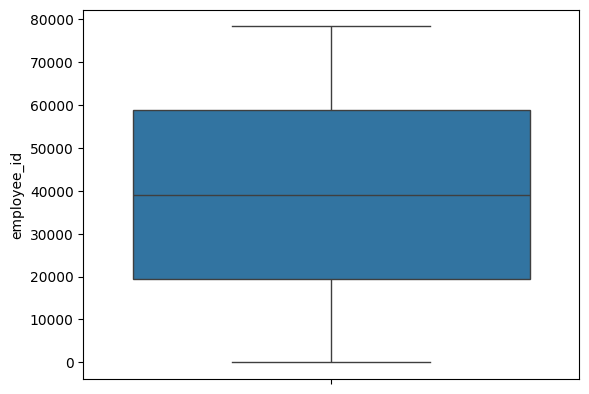

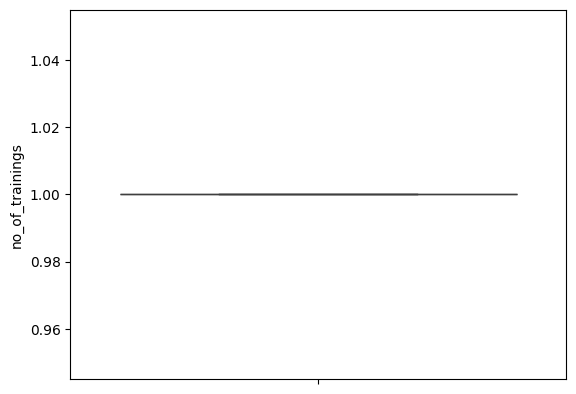

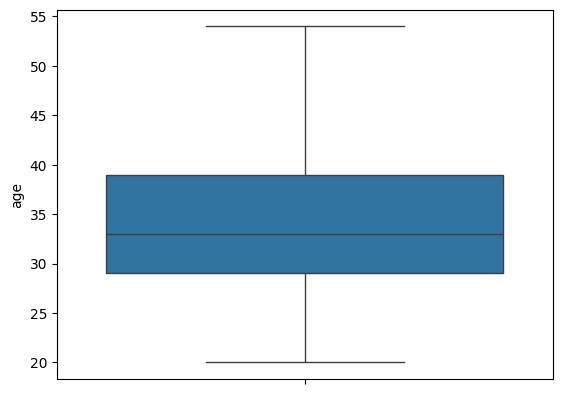

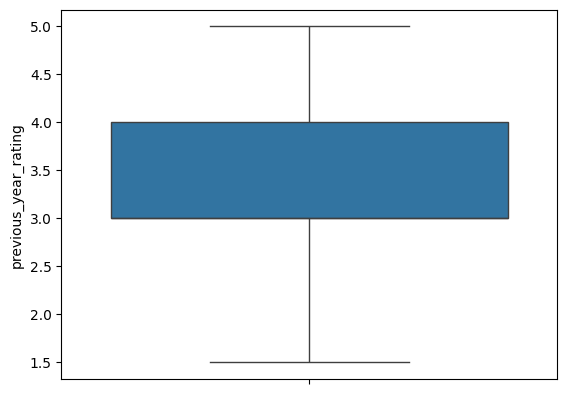

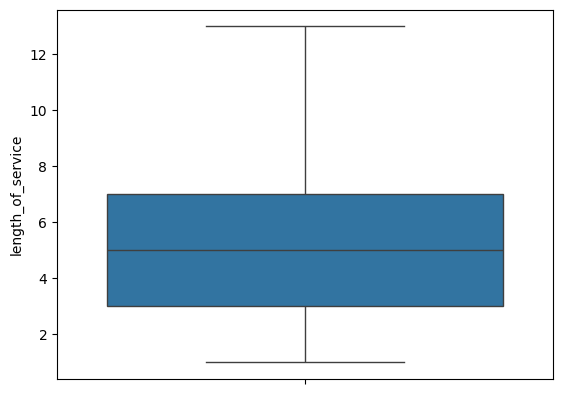

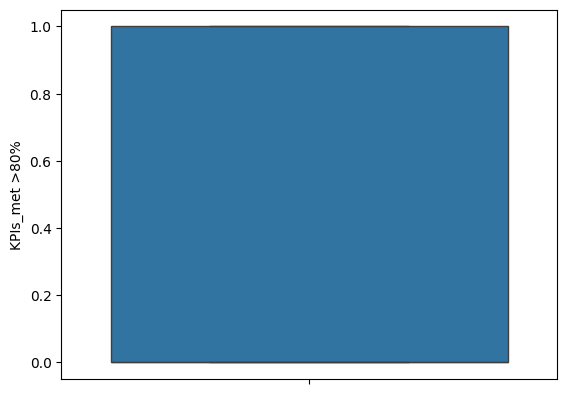

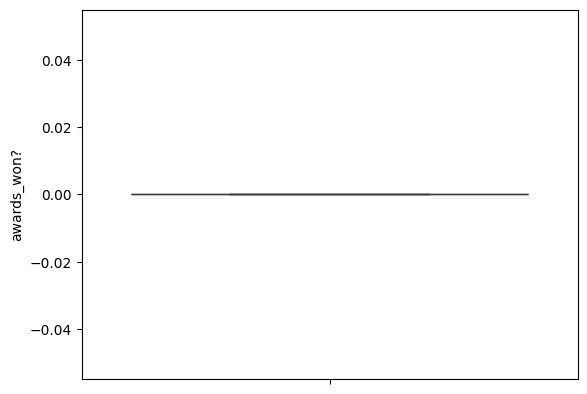

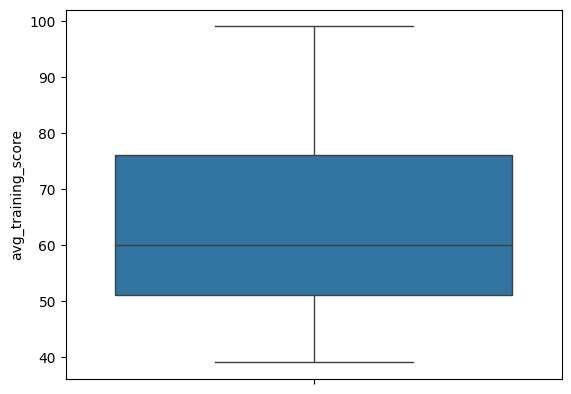

In [726]:

# Now Lets's check for outliners in data
import matplotlib.pyplot as plt

numerical = test.select_dtypes("number")
for i in numerical.columns:
  sea.boxplot(test[i])
  plt.show()


In [727]:

test['age']=np.cbrt(test['age'])
test['length_of_service']=np.cbrt(test['length_of_service'])
test['KPIs_met >80%']=np.cbrt(test['KPIs_met >80%'])



In [728]:
#Now let's encode the cat values
cat1 = test.select_dtypes('object')
cat1.head(3)


,department,region,education,gender,recruitment_channel
0,Technology,region_26,Bachelor's,m,sourcing
1,HR,region_4,Bachelor's,f,other
2,Sales & Marketing,region_13,Bachelor's,m,other


In [729]:
cat1 = cat1.drop(['region'],axis=1)

In [730]:
department_new = test.groupby('department')['KPIs_met >80%'].mean()
cat1['department'] = cat1['department'].map(department_new)


In [731]:
cat_colum1 = cat1.select_dtypes('object').columns
cat_colum1


Index(['education', 'gender', 'recruitment_channel'], dtype='object')

In [732]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore',drop='first', sparse_output=False)  # sparse=False forces dense output
X_cat1 = ohe.fit_transform(test[cat_colum])
#Here we are creating a table that' swhy to get all column name we have given get_feature_names_out(cat_column)
X_cat1 = pd.DataFrame(X_cat, columns=ohe.get_feature_names_out(cat_colum), index=test.index)


In [733]:
X_cat1['department']=cat['department']
X_cat1

,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing,department
0,0.0,1.0,0.0,0.0,1.0,0.265083
1,0.0,0.0,1.0,0.0,0.0,0.430737
2,0.0,0.0,1.0,0.0,1.0,0.265083
3,0.0,0.0,1.0,0.0,0.0,0.265083
4,0.0,0.0,1.0,0.0,0.0,0.344354
...,...,...,...,...,...,...
23485,0.0,0.0,1.0,0.0,1.0,0.416416
23486,0.0,1.0,1.0,0.0,1.0,0.377557
23487,0.0,0.0,1.0,0.0,0.0,0.265083
23488,0.0,0.0,1.0,0.0,0.0,0.334160


In [734]:

Num_col1= test.select_dtypes('number').columns


In [735]:
X_final2 = pd.concat([test[Num_col1], X_cat1], axis=1)

X_final2.head(3)


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing,department
0,8724,1,2.884499,3.0,1.000000,1.0,0,77,0.0,1.0,0.0,0.0,1.0,0.265083
1,74430,1,3.141381,3.0,1.709976,0.0,0,51,0.0,0.0,1.0,0.0,0.0,0.430737
2,72255,1,3.141381,1.5,1.587401,0.0,0,47,0.0,0.0,1.0,0.0,1.0,0.265083


In [738]:
# Make predictions
y_pred = logreg.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [739]:
accuracy_score(y_test,y_pred)

0.9204495694059261

In [741]:
y_pred1 = logreg.predict(X_final)
y_pred1

array([0, 0, 0, ..., 0, 0, 0])

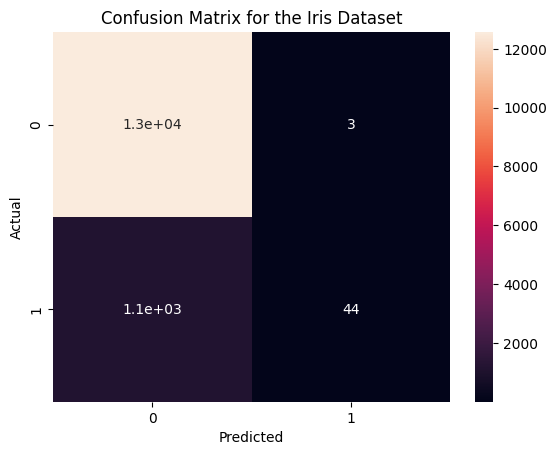

In [742]:
cm=confusion_matrix(y_test, y_pred)
import matplotlib.pyplot as plt
sea.heatmap(cm,annot=True,xticklabels=y.unique(),yticklabels=y.unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the Iris Dataset')
plt.show()

In [743]:
# Classification report
cr = classification_report(y_test, y_pred)
print("Classification Report:")
print(cr)


Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     12571
           1       0.94      0.04      0.07      1131

    accuracy                           0.92     13702
   macro avg       0.93      0.52      0.52     13702
weighted avg       0.92      0.92      0.89     13702



In [744]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:")
print(accuracy)

Accuracy Score:
0.9204495694059261


In [745]:
y_pred #predicted

array([0, 0, 0, ..., 0, 0, 0])

In [746]:
from sklearn.neighbors import KNeighborsClassifier

# Create a KNN classifier
knn = KNeighborsClassifier(n_neighbors=5) #tuning (best parameters)

# Fit the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [750]:
knn_y_pred = knn.predict(X_test)
knn_y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [751]:
knn_y_pred1 = knn.predict(X_final2)
knn_y_pred1

array([0, 0, 0, ..., 0, 1, 0])

In [752]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,knn_y_pred)

0.9119836520216027

In [753]:
print(classification_report(y_test,knn_y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     12571
           1       0.36      0.09      0.14      1131

    accuracy                           0.91     13702
   macro avg       0.64      0.54      0.55     13702
weighted avg       0.88      0.91      0.89     13702



In [754]:
from sklearn.tree import DecisionTreeClassifier #knn module?? sklearn.neighbors
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Make predictions
dt_y_pred = dt.predict(X_test)


# Evaluate model
print("Accuracy:", accuracy_score(y_test, dt_y_pred))

Accuracy: 0.8991388118522844


In [790]:
dt_y_pred1 = dt.predict(X_final2)
dt_y_pred1

array([1, 1, 1, ..., 1, 1, 1])

In [757]:
confusion_matrix(y_test, dt_y_pred)

array([[11799,   772],
       [  610,   521]])

In [758]:
print(classification_report(y_test,dt_y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94     12571
           1       0.40      0.46      0.43      1131

    accuracy                           0.90     13702
   macro avg       0.68      0.70      0.69     13702
weighted avg       0.91      0.90      0.90     13702



In [759]:
from sklearn.ensemble import RandomForestClassifier
#log.regg=linearmodel, knn=neighbours ,dt=tree
#ensemble:together/ collection of dt
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, rf_y_pred)
print("Accuracy: ",accuracy)

Accuracy:  0.9376003503138228


In [791]:
rf_y_pred1 = rf_model.predict(X_final2)
rf_y_pred1

array([1, 1, 1, ..., 1, 1, 1])

In [762]:
from sklearn.ensemble import RandomForestClassifier
# Create an AdaBoost model with a Decision Tree as the weak learner
adaboost_model = RandomForestClassifier()

# Train the model
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set

ada_y_pred = adaboost_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, ada_y_pred)
print(f'Accuracy of AdaBoost: {accuracy:.2f}')

Accuracy of AdaBoost: 0.94


In [801]:
ada_y_pred1 = adaboost_model.predict(X_final2)
ada_y_pred1= pd.DataFrame(ada_y_pred1)
ada_y_pred1.to_csv("/content/output.csv", index=False)

In [764]:

from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
# Create a Gradient Boosting model
gradient_boosting_model = GradientBoostingClassifier()

# Train the model
gradient_boosting_model.fit(X_train, y_train)

# Make predictions on the test set
gra_y_pred = gradient_boosting_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, gra_y_pred)
print(f'Accuracy of Gradient Boosting: {accuracy:.2f}')

Accuracy of Gradient Boosting: 0.94


In [798]:
gra_y_pred1 = gradient_boosting_model.predict(X_final2)
gra_y_pred1 = pd.DataFrame(gra_y_pred1)
gra_y_pred1.to_csv("/content/output.csv", index=False)

In [767]:
from sklearn.svm import SVC
# Train SVM classifier
svm_classifier = SVC()
svm_classifier.fit(X_train, y_train)

# Make predictions
svm_y_pred = svm_classifier.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test,svm_y_pred)
print(f'SVM Accuracy: {accuracy}')


SVM Accuracy: 0.921690264195008


In [768]:
svm_y_pred1 = svm_classifier.predict(X_final)
svm_y_pred1

array([0, 0, 0, ..., 0, 0, 0])

In [769]:
from sklearn.naive_bayes import GaussianNB
# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions
gn_y_pred = gnb.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, gn_y_pred)
print(f'Gaussian Naive Bayes Accuracy: {accuracy}')

Gaussian Naive Bayes Accuracy: 0.8976791709239527


In [797]:
gn_y_pred1 = gnb.predict(X_final2)
gn_y_pred1 = pd.DataFrame(gn_y_pred1)
gn_y_pred1

,0
0,1
1,1
2,1
3,1
4,1
...,...
23485,1
23486,1
23487,1
23488,1


In [777]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

predictions = {
    "KNN": knn_y_pred,
    "Decision Tree": dt_y_pred,
    "Random Forest": rf_y_pred,
    "AdaBoost": ada_y_pred,
    "SVM": svm_y_pred,
    "Gaussian Naive Bayes": gn_y_pred,
    "Gradient Booster":gra_y_pred,
}

# Initialize a dictionary to store metrics
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

# Compute metrics for each model
for model_name, y_pred in predictions.items():
    results["Model"].append(model_name)
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred, average='macro'))
    results["Recall"].append(recall_score(y_test, y_pred, average='macro'))
    results["F1-Score"].append(f1_score(y_test, y_pred, average='macro'))

results

{'Model': ['KNN',
  'Decision Tree',
  'Random Forest',
  'AdaBoost',
  'SVM',
  'Gaussian Naive Bayes',
  'Gradient Booster'],
 'Accuracy': [0.9119836520216027,
  0.8991388118522844,
  0.9376003503138228,
  0.936870529849657,
  0.921690264195008,
  0.8976791709239527,
  0.9397168296599037],
 'Precision': [0.6439492030198523,
  0.6768905162451946,
  0.9042548837716905,
  0.8992391806748242,
  0.9606786866021695,
  0.5774237619260904,
  0.9446561047686597],
 'Recall': [0.5376505129028041,
  0.6996215518841487,
  0.6417292308423785,
  0.638515302049874,
  0.5256410256410257,
  0.5362917936465703,
  0.6416757415580652],
 'F1-Score': [0.5485370782567948,
  0.6872718636955769,
  0.6994404150341751,
  0.6951618531320265,
  0.52831510539023,
  0.5443116080368061,
  0.703122578560228]}

In [778]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results)


# Display the results
print(results_df)

                  Model  Accuracy  Precision    Recall  F1-Score
0                   KNN  0.911984   0.643949  0.537651  0.548537
1         Decision Tree  0.899139   0.676891  0.699622  0.687272
2         Random Forest  0.937600   0.904255  0.641729  0.699440
3              AdaBoost  0.936871   0.899239  0.638515  0.695162
4                   SVM  0.921690   0.960679  0.525641  0.528315
5  Gaussian Naive Bayes  0.897679   0.577424  0.536292  0.544312
6      Gradient Booster  0.939717   0.944656  0.641676  0.703123


In [779]:
# Sort by F1-Score (or any other metric you prefer)
results_df = results_df.sort_values(by="F1-Score",ascending=False)
print(results_df)

                  Model  Accuracy  Precision    Recall  F1-Score
6      Gradient Booster  0.939717   0.944656  0.641676  0.703123
2         Random Forest  0.937600   0.904255  0.641729  0.699440
3              AdaBoost  0.936871   0.899239  0.638515  0.695162
1         Decision Tree  0.899139   0.676891  0.699622  0.687272
0                   KNN  0.911984   0.643949  0.537651  0.548537
5  Gaussian Naive Bayes  0.897679   0.577424  0.536292  0.544312
4                   SVM  0.921690   0.960679  0.525641  0.528315
